# Structural Analysis of a Boolean GRN

This notebook is intentionally focused on **network structure only**:
- directed graph reconstruction from Boolean rules,
- FVS computation and structural bounds,
- feedback-loop analysis,
- structural visualization and result export.

It does **not** perform attractor control.

## 1) Library Imports

In [24]:
from itertools import combinations
from pathlib import Path
import json

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from biodivine_aeon import BooleanNetwork

## 2) Boolean Rule Set

Defines candidate inferred GRNs selecting one for the analysis.

In [25]:
rules = {
    "rule": """COUP, !FGF8\nEMX2, !SP8\nFGF8, SP8\nPAX6, SP8\nSP8, FGF8""",
    "rule_2": "COUP, EMX2\nEMX2, !FGF8\nFGF8, SP8\nPAX6, !EMX2\nSP8, FGF8",
    "next_r": "COUP,   !SP8&!PAX6&COUP | !FGF8 | EMX2\nEMX2,   !SP8 | !FGF8 | EMX2\nFGF8,   PAX6 | !COUP\nPAX6,   !EMX2\nSP8,    !EMX2\n",
}

active_rule_name = "next_r" # Variable for the rule being analyzed
rule_text = rules[active_rule_name] # Text of the rule being analyzed

print(f"Using inferred GRN: {active_rule_name}")
print(rule_text)

Using inferred GRN: next_r
COUP,   !SP8&!PAX6&COUP | !FGF8 | EMX2
EMX2,   !SP8 | !FGF8 | EMX2
FGF8,   PAX6 | !COUP
PAX6,   !EMX2
SP8,    !EMX2



## 3) Core Functions

Defines reusable structural analysis functions:
- graph building from BNET rules,
- exact (or fallback greedy) minimum FVS search,
- structural driver/sensor upper bounds,
- directed feedback-loop enumeration,
- FVS summary table construction.

In [26]:
# Build the Boolean network and its corresponding graph
def build_bn_and_graph(rule_text):
    """Parse bnet rules into an AEON network and a NetworkX DiGraph."""
    bn = BooleanNetwork.from_bnet(rule_text)
    graph = nx.DiGraph()

    for name in bn.variable_names():
        graph.add_node(name)

    for reg in bn.regulations():
        src = bn.get_variable_name(reg["source"])
        tgt = bn.get_variable_name(reg["target"])
        graph.add_edge(src, tgt, sign=reg.get("sign"), essential=reg.get("essential", None))

    return bn, graph

# Find minimum FVS (exact approach for small graphs and a greedy fallback for larger ones)
def minimum_fvs_sets_exact(graph, max_nodes_exact=18):
    """Return all minimum-cardinality FVS solutions for small/medium graphs."""
    n_nodes = graph.number_of_nodes()
    nodes = list(graph.nodes())

    if nx.is_directed_acyclic_graph(graph):
        return [set()]

    if n_nodes > max_nodes_exact:
        g_work = graph.copy()
        picked = set()
        while not nx.is_directed_acyclic_graph(g_work):
            score = {
                node: g_work.in_degree(node) * g_work.out_degree(node)
                for node in g_work.nodes()
            }
            to_remove = max(score, key=score.get)
            picked.add(to_remove)
            g_work.remove_node(to_remove)
        return [picked]

    for k in range(1, n_nodes + 1):
        solutions = []
        for subset in combinations(nodes, k):
            reduced = graph.copy()
            reduced.remove_nodes_from(subset)
            if nx.is_directed_acyclic_graph(reduced):
                solutions.append(set(subset))
        if solutions:
            return solutions

    return [set(nodes)]

# Compute structural upper bounds from source/sink nodes and minimum FVSs
def structural_control_bounds(rule_text, max_nodes_exact=18):
    """Compute structural upper bounds from source/sink nodes and minimum FVSs."""
    bn, graph = build_bn_and_graph(rule_text)

    source_nodes = sorted([n for n in graph.nodes if graph.in_degree(n) == 0])
    sink_nodes = sorted([n for n in graph.nodes if graph.out_degree(n) == 0])

    fvs_forward_aeon = sorted(bn.get_variable_name(v) for v in bn.feedback_vertex_set())
    fvs_forward_all = [sorted(s) for s in minimum_fvs_sets_exact(graph, max_nodes_exact=max_nodes_exact)]
    fvs_reverse_all = [
        sorted(s)
        for s in minimum_fvs_sets_exact(graph.reverse(copy=True), max_nodes_exact=max_nodes_exact)
    ]

    fvs_forward_choice = fvs_forward_all[0] if fvs_forward_all else []
    fvs_reverse_choice = fvs_reverse_all[0] if fvs_reverse_all else []

    driver_upper_bound = sorted(set(source_nodes) | set(fvs_forward_choice))
    sensor_upper_bound = sorted(set(sink_nodes) | set(fvs_reverse_choice))

    metrics = {
        "n_nodes": graph.number_of_nodes(),
        "n_edges": graph.number_of_edges(),
        "n_sources": len(source_nodes),
        "n_sinks": len(sink_nodes),
        "min_fvs_size_forward": len(fvs_forward_choice),
        "min_fvs_size_reverse": len(fvs_reverse_choice),
        "driver_upper_bound_size": len(driver_upper_bound),
        "sensor_upper_bound_size": len(sensor_upper_bound),
    }

    return {
        "bn": bn,
        "graph": graph,
        "source_nodes": source_nodes,
        "sink_nodes": sink_nodes,
        "fvs_forward_aeon": fvs_forward_aeon,
        "fvs_forward_all": fvs_forward_all,
        "fvs_reverse_all": fvs_reverse_all,
        "driver_upper_bound": driver_upper_bound,
        "sensor_upper_bound": sensor_upper_bound,
        "metrics": metrics,
    }

# Enumerate feedback loops and return a tabular summary
def feedback_loops_dataframe(graph, max_cycles=2000):
    """Enumerate directed cycles and return a tabular summary."""
    rows = []
    truncated = False

    for i, cycle in enumerate(nx.simple_cycles(graph), start=1):
        if i > max_cycles:
            truncated = True
            break

        cycle_edges = []
        for idx, src in enumerate(cycle):
            tgt = cycle[(idx + 1) % len(cycle)]
            cycle_edges.append(f"{src}->{tgt}")

        rows.append({
            "cycle_index": i,
            "cycle_length": len(cycle),
            "cycle_nodes": " -> ".join(cycle + [cycle[0]]),
            "cycle_edges": ", ".join(cycle_edges),
        })

    if not rows:
        df = pd.DataFrame(columns=["cycle_index", "cycle_length", "cycle_nodes", "cycle_edges"])
        return df, truncated

    df = pd.DataFrame(rows).sort_values(["cycle_length", "cycle_index"]).reset_index(drop=True)
    return df, truncated

# Build a DataFrame summarizing the minimum FVS solutions
def build_fvs_dataframe(struct):
    rows = [
        {
            "solution_type": "forward_min_fvs",
            "nodes": ", ".join(nodes),
            "size": len(nodes),
        }
        for nodes in struct["fvs_forward_all"]
    ]
    rows.extend(
        {
            "solution_type": "reverse_min_fvs",
            "nodes": ", ".join(nodes),
            "size": len(nodes),
        }
        for nodes in struct["fvs_reverse_all"]
    )
    return pd.DataFrame(rows)

## 4) Structural Analysis

Executes the core pipeline and prints the main structural results (source/sink nodes, structural bounds, minimum FVS), then shows a compact metrics table.

In [27]:
struct = structural_control_bounds(rule_text, max_nodes_exact=18)
graph = struct["graph"]

metrics_df = pd.DataFrame(struct["metrics"], index=[0]).T.rename(columns={0: "value"})
metrics_df.index.name = "metric"

fvs_df = build_fvs_dataframe(struct)
feedback_df, feedback_truncated = feedback_loops_dataframe(graph, max_cycles=2000)

metrics_df.loc["n_feedback_loops", "value"] = int(feedback_df.shape[0])
metrics_df.loc["feedback_loop_truncated", "value"] = int(feedback_truncated)

print("Source nodes:", struct["source_nodes"])
print("Sink nodes:", struct["sink_nodes"])
print("Driver upper bound:", struct["driver_upper_bound"])
print("Sensor upper bound:", struct["sensor_upper_bound"])
print("Forward AEON minimum FVS:", struct["fvs_forward_aeon"])
print("Number of feedback loops:", feedback_df.shape[0])

metrics_df

Source nodes: []
Sink nodes: []
Driver upper bound: ['COUP', 'EMX2']
Sensor upper bound: ['COUP', 'EMX2']
Forward AEON minimum FVS: ['COUP', 'EMX2']
Number of feedback loops: 8


,value
metric,
n_nodes,5.0
n_edges,12.0
n_sources,0.0
n_sinks,0.0
min_fvs_size_forward,2.0
min_fvs_size_reverse,2.0
driver_upper_bound_size,2.0
sensor_upper_bound_size,2.0
n_feedback_loops,8.0


## 5) FVS and Feedback Loop Solutions

Displays:
- all minimum FVS solutions found for forward/reverse graphs,
- the first feedback loops (cycles) detected in the network.

In [28]:
from IPython.display import display

print("Minimum FVS solutions (forward and reverse):")
display(fvs_df)

print("First feedback loops detected (up to first 20 shown):")
display(feedback_df.head(20))

if feedback_truncated:
    print("Note: feedback loop list was truncated by max_cycles.")

Minimum FVS solutions (forward and reverse):


,solution_type,nodes,size
0,forward_min_fvs,"COUP, EMX2",2
1,reverse_min_fvs,"COUP, EMX2",2


First feedback loops detected (up to first 20 shown):


,cycle_index,cycle_length,cycle_nodes,cycle_edges
0,1,1,COUP -> COUP,COUP->COUP
1,2,1,EMX2 -> EMX2,EMX2->EMX2
2,3,2,COUP -> FGF8 -> COUP,"COUP->FGF8, FGF8->COUP"
3,7,2,SP8 -> EMX2 -> SP8,"SP8->EMX2, EMX2->SP8"
4,4,3,COUP -> FGF8 -> EMX2 -> COUP,"COUP->FGF8, FGF8->EMX2, EMX2->COUP"
5,8,3,EMX2 -> PAX6 -> FGF8 -> EMX2,"EMX2->PAX6, PAX6->FGF8, FGF8->EMX2"
6,5,4,COUP -> FGF8 -> EMX2 -> PAX6 -> COUP,"COUP->FGF8, FGF8->EMX2, EMX2->PAX6, PAX6->COUP"
7,6,4,COUP -> FGF8 -> EMX2 -> SP8 -> COUP,"COUP->FGF8, FGF8->EMX2, EMX2->SP8, SP8->COUP"


## 6) Visualization

Builds a two-panel figure:
- left: GRN with node colors by structural role (driver/sensor/FVS overlap),
- right: bar chart with structural set sizes.

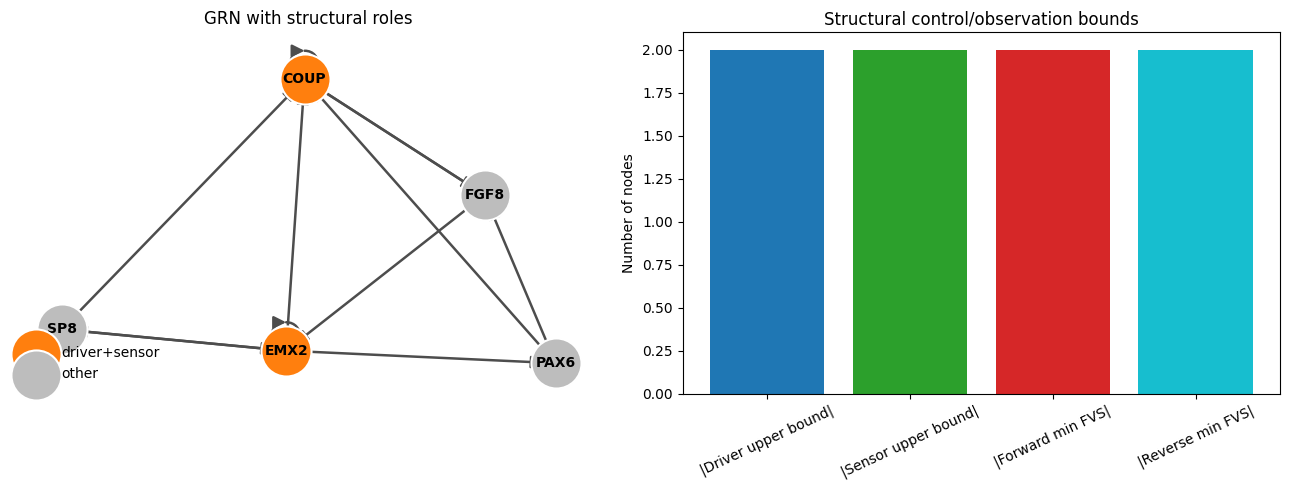

In [29]:
node_role = {}
for node in graph.nodes:
    in_driver = node in struct["driver_upper_bound"]
    in_sensor = node in struct["sensor_upper_bound"]
    in_fvs = any(node in s for s in struct["fvs_forward_all"])

    if in_driver and in_sensor:
        node_role[node] = "driver+sensor"
    elif in_driver:
        node_role[node] = "driver-bound"
    elif in_sensor:
        node_role[node] = "sensor-bound"
    elif in_fvs:
        node_role[node] = "fvs-only"
    else:
        node_role[node] = "other"

role_color = {
    "driver+sensor": "#ff7f0e",
    "driver-bound": "#1f77b4",
    "sensor-bound": "#2ca02c",
    "fvs-only": "#9467bd",
    "other": "#bdbdbd",
}

pos = nx.spring_layout(graph, seed=7)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nx.draw_networkx_edges(
    graph,
    pos,
    ax=axes[0],
    arrowstyle="-|>",
    arrowsize=18,
    width=1.8,
    edge_color="#4d4d4d",
)

for role, color in role_color.items():
    nodes = [n for n, r in node_role.items() if r == role]
    if nodes:
        nx.draw_networkx_nodes(
            graph,
            pos,
            nodelist=nodes,
            ax=axes[0],
            node_color=color,
            node_size=1300,
            edgecolors="white",
            linewidths=1.5,
            label=role,
        )

nx.draw_networkx_labels(graph, pos, ax=axes[0], font_size=10, font_weight="bold")
axes[0].set_title("GRN with structural roles")
axes[0].axis("off")
axes[0].legend(loc="lower left", frameon=False)

bound_sizes = pd.Series({
    "|Driver upper bound|": len(struct["driver_upper_bound"]),
    "|Sensor upper bound|": len(struct["sensor_upper_bound"]),
    "|Forward min FVS|": len(struct["fvs_forward_all"][0]) if struct["fvs_forward_all"] else 0,
    "|Reverse min FVS|": len(struct["fvs_reverse_all"][0]) if struct["fvs_reverse_all"] else 0,
})

axes[1].bar(bound_sizes.index, bound_sizes.values, color=["#1f77b4", "#2ca02c", "#d62728", "#17becf"])
axes[1].set_ylabel("Number of nodes")
axes[1].set_title("Structural control/observation bounds")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 7) Save Outputs

Writes all structural outputs to disk:
- metrics table,
- FVS solutions table,
- feedback-loop table,
- JSON summary with structural bounds.

In [31]:
out_dir = Path("outputs/structure_notebook")
out_dir.mkdir(parents=True, exist_ok=True)

metrics_path = out_dir / "metrics.csv"
fvs_path = out_dir / "fvs_solutions.csv"
loops_path = out_dir / "feedback_loops.csv"
bounds_path = out_dir / "bounds.json"

metrics_df.reset_index().to_csv(metrics_path, index=False)
fvs_df.to_csv(fvs_path, index=False)
feedback_df.to_csv(loops_path, index=False)

bounds_payload = {
    "source_nodes": struct["source_nodes"],
    "sink_nodes": struct["sink_nodes"],
    "fvs_forward_aeon": struct["fvs_forward_aeon"],
    "fvs_forward_all": struct["fvs_forward_all"],
    "fvs_reverse_all": struct["fvs_reverse_all"],
    "driver_upper_bound": struct["driver_upper_bound"],
    "sensor_upper_bound": struct["sensor_upper_bound"],
    "feedback_loop_count": int(feedback_df.shape[0]),
    "feedback_loop_truncated": feedback_truncated,
}

bounds_path.write_text(json.dumps(bounds_payload, indent=2), encoding="utf-8")

print(f"Saved metrics: {metrics_path}")
print(f"Saved FVS solutions: {fvs_path}")
print(f"Saved feedback loops: {loops_path}")
print(f"Saved structural bounds JSON: {bounds_path}")

Saved metrics: outputs/structure_notebook/metrics.csv
Saved FVS solutions: outputs/structure_notebook/fvs_solutions.csv
Saved feedback loops: outputs/structure_notebook/feedback_loops.csv
Saved structural bounds JSON: outputs/structure_notebook/bounds.json


## 8) Results Summary

Creates a text summary using the values computed above.

In [32]:
from IPython.display import Markdown, display

best_forward = struct["fvs_forward_all"][0] if struct["fvs_forward_all"] else []
best_reverse = struct["fvs_reverse_all"][0] if struct["fvs_reverse_all"] else []

summary_lines = [
    "### Structural Results Summary",
    f"- Active rule set: **{active_rule_name}**",
    f"- Nodes: **{int(metrics_df.loc['n_nodes', 'value'])}**, Edges: **{int(metrics_df.loc['n_edges', 'value'])}**",
    f"- Source nodes: **{struct['source_nodes']}**",
    f"- Sink nodes: **{struct['sink_nodes']}**",
    f"- One forward minimum FVS (AEON): **{struct['fvs_forward_aeon']}**",
    f"- One forward minimum FVS (enumeration): **{best_forward}**",
    f"- One reverse minimum FVS: **{best_reverse}**",
    f"- Driver upper bound: **{struct['driver_upper_bound']}**",
    f"- Sensor upper bound: **{struct['sensor_upper_bound']}**",
    f"- Feedback loops detected: **{int(feedback_df.shape[0])}**",
]

if feedback_truncated:
    summary_lines.append("- Feedback-loop report was truncated by the max_cycles limit.")

display(Markdown("\n".join(summary_lines)))

### Structural Results Summary
- Active rule set: **next_r**
- Nodes: **5**, Edges: **12**
- Source nodes: **[]**
- Sink nodes: **[]**
- One forward minimum FVS (AEON): **['COUP', 'EMX2']**
- One forward minimum FVS (enumeration): **['COUP', 'EMX2']**
- One reverse minimum FVS: **['COUP', 'EMX2']**
- Driver upper bound: **['COUP', 'EMX2']**
- Sensor upper bound: **['COUP', 'EMX2']**
- Feedback loops detected: **8**